# Monthly Youth Unemployment Statistics

## Dataset Description
Monthly unemployment statistics for **youth aged 15–24 and 15–30**, covering the age group that directly overlaps with fresh graduates entering the labour market. From the DOSM Labour Force Survey (LFS).

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | Department of Statistics Malaysia (DOSM) |
| **Survey** | Labour Force Survey (LFS), monthly |
| **Catalogue** | https://open.dosm.gov.my/data-catalogue/lfs_month_youth |
| **Parquet URL** | `https://storage.dosm.gov.my/labour/lfs_month_youth.parquet` |
| **CSV URL** | `https://storage.dosm.gov.my/labour/lfs_month_youth.csv` |
| **License** | CC BY 4.0 — DOSM |

## Column Descriptions
| Column | Type | Description |
|---|---|---|
| `date` | date | Month (YYYY-MM-DD, DD always = 01) |
| `unemployed_15_24` | float | Number of unemployed persons aged 15–24 ('000) |
| `u_rate_15_24` | float | Unemployment rate for ages 15–24 (%) |
| `unemployed_15_30` | float | Number of unemployed persons aged 15–30 ('000) |
| `u_rate_15_30` | float | Unemployment rate for ages 15–30 (%) |

## Relevance to EduNilai
Youth unemployment directly affects the ROI calculation — a graduate who spends months unemployed after graduation earns nothing, increasing the effective cost of the degree. The 15–30 age band captures the extended transition period into graduate employment. The monthly series also clearly shows the COVID-19 shock (2020–2021) and recovery.

In [1]:
# pip install pandas fastparquet
import pandas as pd
import matplotlib.pyplot as plt
import os

URL = 'https://storage.dosm.gov.my/labour/lfs_month_youth.parquet'
df = pd.read_parquet(URL)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df

,date,unemployed_15_24,u_rate_15_24,unemployed_15_30,u_rate_15_30
0,2016-01-01,283.6,10.7,402.8,6.9
1,2016-02-01,236.1,9.0,340.6,5.7
2,2016-03-01,285.0,10.9,416.1,7.0
3,2016-04-01,305.6,11.5,405.7,6.9
4,2016-05-01,291.6,11.1,395.2,6.8
...,...,...,...,...,...
115,2025-08-01,298.0,10.2,398.7,6.2
116,2025-09-01,296.9,10.1,398.1,6.2
117,2025-10-01,297.6,10.1,398.5,6.1
118,2025-11-01,297.9,10.1,398.0,6.1


In [2]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDate range:", df['date'].min(), "–", df['date'].max())
print("\nDescriptive stats:")
print(df[['u_rate_15_24', 'u_rate_15_30']].describe().round(2))

Shape: (120, 5)
Columns: ['date', 'unemployed_15_24', 'u_rate_15_24', 'unemployed_15_30', 'u_rate_15_30']

Date range: 2016-01-01 00:00:00 – 2025-12-01 00:00:00

Descriptive stats:
       u_rate_15_24  u_rate_15_30
count        120.00        120.00
mean          11.38          7.17
std            1.27          0.94
min            9.00          5.70
25%           10.40          6.60
50%           11.10          6.90
75%           12.10          7.40
max           14.20         10.00


In [2]:
# Annual average for cleaner trend
df_annual = df.set_index('date').resample('A').mean(numeric_only=True).reset_index()

print("Annual average unemployment rates:")
print(df_annual[['date', 'u_rate_15_24', 'u_rate_15_30']].to_string(index=False))

Annual average unemployment rates:
      date  u_rate_15_24  u_rate_15_30
2016-12-31     10.658333      6.716667
2017-12-31     11.325000      6.925000
2018-12-31     11.108333      6.833333
2019-12-31     10.375000      6.783333
2020-12-31     12.708333      8.566667
2021-12-31     13.633333      8.800000
2022-12-31     12.408333      7.483333
2023-12-31     10.941667      6.791667
2024-12-31     10.483333      6.616667
2025-12-31     10.200000      6.200000


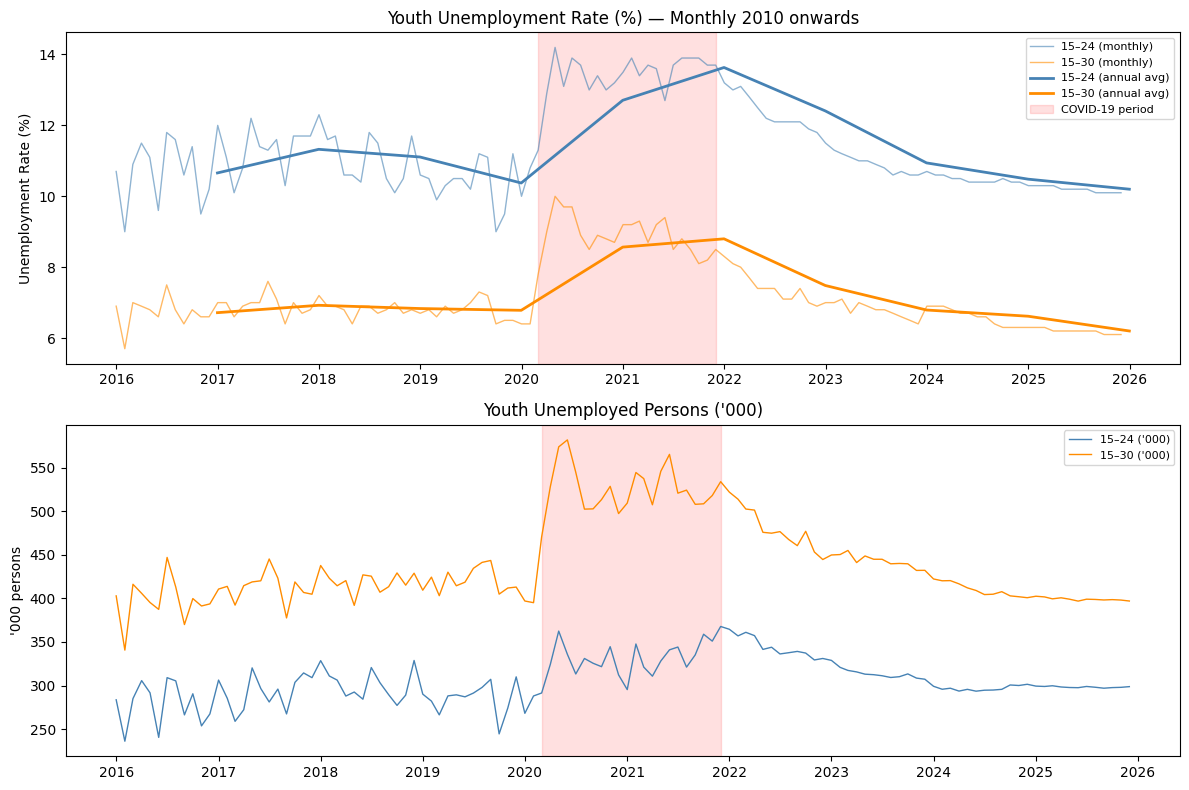

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Unemployment rate trend — both age bands
axes[0].plot(df['date'], df['u_rate_15_24'], color='steelblue',
             linewidth=1, alpha=0.6, label='15–24 (monthly)')
axes[0].plot(df['date'], df['u_rate_15_30'], color='darkorange',
             linewidth=1, alpha=0.6, label='15–30 (monthly)')
axes[0].plot(df_annual['date'], df_annual['u_rate_15_24'], color='steelblue',
             linewidth=2, label='15–24 (annual avg)')
axes[0].plot(df_annual['date'], df_annual['u_rate_15_30'], color='darkorange',
             linewidth=2, label='15–30 (annual avg)')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
                alpha=0.12, color='red', label='COVID-19 period')
axes[0].set_title('Youth Unemployment Rate (%) — Monthly 2010 onwards')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].legend(fontsize=8)

# Headcount trend
axes[1].plot(df['date'], df['unemployed_15_24'], color='steelblue',
             linewidth=1, label="15–24 ('000)")
axes[1].plot(df['date'], df['unemployed_15_30'], color='darkorange',
             linewidth=1, label="15–30 ('000)")
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
                alpha=0.12, color='red')
axes[1].set_title("Youth Unemployed Persons ('000)")
axes[1].set_ylabel("'000 persons")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
# check df before exporting to csv
df

,date,unemployed_15_24,u_rate_15_24,unemployed_15_30,u_rate_15_30
0,2016-01-01,283.6,10.7,402.8,6.9
1,2016-02-01,236.1,9.0,340.6,5.7
2,2016-03-01,285.0,10.9,416.1,7.0
3,2016-04-01,305.6,11.5,405.7,6.9
4,2016-05-01,291.6,11.1,395.2,6.8
...,...,...,...,...,...
115,2025-08-01,298.0,10.2,398.7,6.2
116,2025-09-01,296.9,10.1,398.1,6.2
117,2025-10-01,297.6,10.1,398.5,6.1
118,2025-11-01,297.9,10.1,398.0,6.1


In [5]:
os.makedirs('../data/salary', exist_ok=True)
df.to_csv('../data/salary/youth_unemployment_monthly.csv', index=False, encoding='utf-8')
print("Saved -> ../data/salary/youth_unemployment_monthly.csv")
print(f"Rows: {len(df)}")

Saved -> ../data/salary/youth_unemployment_monthly.csv
Rows: 120
